In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")

file_path = '/content/winemag-data_first150k.csv'
df = pd.read_csv(file_path)




In [13]:
df.shape
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150930 entries, 0 to 150929
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Unnamed: 0   150930 non-null  int64  
 1   country      150925 non-null  object 
 2   description  150930 non-null  object 
 3   designation  105195 non-null  object 
 4   points       150930 non-null  int64  
 5   price        137235 non-null  float64
 6   province     150925 non-null  object 
 7   region_1     125870 non-null  object 
 8   region_2     60953 non-null   object 
 9   variety      150930 non-null  object 
 10  winery       150930 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.7+ MB


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,variety,winery
count,150930.000000,150925,150930,105195,150930.000000,137235.000000,150925,125870,60953,150930,150930
unique,NaN,48,97821,30621,NaN,NaN,455,1236,18,632,14810
top,NaN,US,"92-94 Barrel sample. A rounded wine, its tanni...",Reserve,NaN,NaN,California,Napa Valley,Central Coast,Chardonnay,Williams Selyem
freq,NaN,62397,6,2752,NaN,NaN,44508,6209,13057,14482,374
mean,75464.500000,NaN,NaN,NaN,87.888418,33.131482,NaN,NaN,NaN,NaN,NaN
std,43569.882402,NaN,NaN,NaN,3.222392,36.322536,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,80.000000,4.000000,NaN,NaN,NaN,NaN,NaN
25%,37732.250000,NaN,NaN,NaN,86.000000,16.000000,NaN,NaN,NaN,NaN,NaN
50%,75464.500000,NaN,NaN,NaN,88.000000,24.000000,NaN,NaN,NaN,NaN,NaN
75%,113196.750000,NaN,NaN,NaN,90.000000,40.000000,NaN,NaN,NaN,NaN,NaN


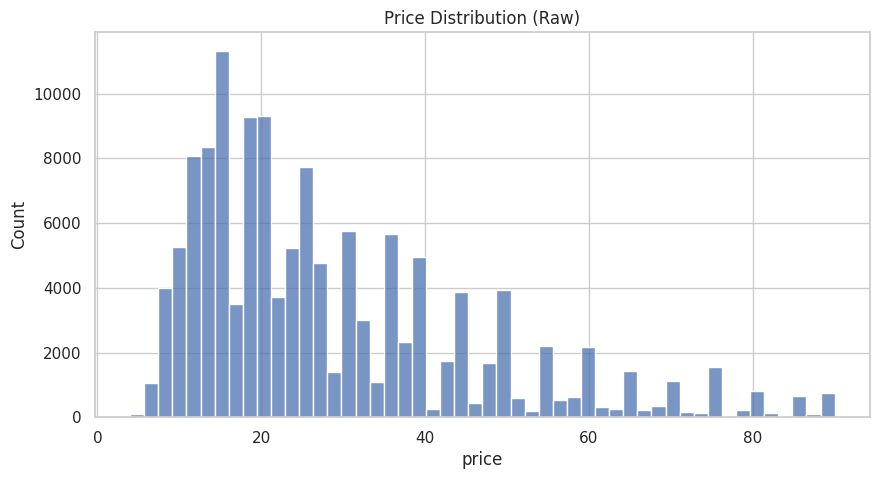

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution (Raw)")
plt.show()

In [ ]:
#Data Checking!
df.isna().sum()
df.duplicated().sum()
df['price'].describe()
df['points'].describe()

In [ ]:
#Data Cleaning
(df.isna().sum() / len(df)) * 100 #Check for missing values
df.duplicated().sum() #Check for duplicates
df['points'].describe()

In [34]:
#Elimite extreme outliers
upper_limit = df['price'].quantile(0.99)
df = df[df['price'] <= upper_limit] #Elimite extreme outliers
#Remove spaces and differences in typing between inputs of data set
text_cols = ['country', 'province', 'region_1', 'region_2', 'variety', 'winery', 'designation']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()


In [ ]:
# Distribution of Points
# This shows how wine ratings are spread across this dataset.

plt.figure(figsize=(10,5))
sns.histplot(df['points'], bins=30, kde=True)
plt.title("Distribution of Wine Ratings (Points)")
plt.xlabel("Points")
plt.ylabel("Count")
plt.show()

# Summary statistics for points
df['points'].describe()


In [ ]:
# Distribution of Price
# Visualises how wine prices are spread across this dataset minus outliers.

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50)
plt.title("Distribution of Wine Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

# Summary statistics for price
df['price'].describe()


In [ ]:
# Univariate Analysis Step 3: Top Countries
# Shows which countries appear most often in the dataset.

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Number of Reviews")
plt.xlabel("Country")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

top_countries


In [ ]:
# Top Varieties of grape
# Shows which grape types are most common.

top_varieties = df['variety'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_varieties.index, y=top_varieties.values)
plt.title("Top 10 Wine Varieties")
plt.xlabel("Variety")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

top_varieties


In [ ]:
# The Top Wineries!
#

top_wineries = df['winery'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_wineries.index, y=top_wineries.values)
plt.title("Top 10 Wineries by Number of Reviews")
plt.xlabel("Winery")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

top_wineries
